# 12 — Combined DCA account: VWB 3x + pump_dump, $1000 + $200/mo (2024→2026, all data)

"How do the two strategies work *together* on one real account?" A dollar-cost-average
account: **$1000 initial + $200 every month**, from 2024 across the **full available
data** (2024-01 → 2026-04; SOL delists 2025-07, the rest run to 2026-04).

Both legs are the corrected streams from nb11 (VWB champion at **3x**; pump_dump surviving
book, WF-classifier filter + catastrophe stop + capacity/slippage engine, per-leg
**pump 8% / dump 3%**). We take each leg's daily return, blend at a fixed target weight
`w·VWB + (1-w)·PD` (daily-rebalanced), and DCA into the blend with proper **NAV/unit
accounting** — monthly cash buys units at the current NAV, so contributions never create
fake return jumps. Risk metrics (Sharpe / Sortino / drawdown) are on the **per-unit NAV**
(the strategy), while the headline dollars and IRR are money-weighted on the account.

In [1]:
import sys, heapq
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.optimize import brentq
from IPython.display import display

sys.path.insert(0, ".")
from _lab import strategy, run_pair, show

REPO = Path("_lab.py").resolve().parents[2]
PD_OUT = REPO / "notebooks" / "pump_dump_combined" / "_out"
START, END = "2024-01-01", "2026-05-01"     # full available span (data ends 2026-04)
INIT, MONTHLY = 1000.0, 200.0
F_PUMP, F_DUMP, LEV = 0.08, 0.03, 3.0
print("account: $%.0f init + $%.0f/mo | window %s -> data end | pump%.0f%%/dump%.0f%% | VWB %gx"
      % (INIT, MONTHLY, START, F_PUMP*100, F_DUMP*100, LEV))

account: $1000 init + $200/mo | window 2024-01-01 -> data end | pump8%/dump3% | VWB 3x


## 1. Rebuild both daily-return streams (as nb11)

In [2]:
GIVEBACKS=[0.005,0.01,0.02,0.03,0.05,0.08,np.inf]; PG,DG=6,6
PF=["r1","r3","r5","r15","r30","accel5","surge15","surge1","rvol60","rng5","dist_hi240","dist_lo60"]
DF=["r1","r3","r5","r15","r30","r60","accel","surge15","surge1","volreg","rng15","hi_d","lo_d","dstreak"]
def naive(s):
    s=pd.to_datetime(s); return s.dt.tz_localize(None) if s.dt.tz is not None else s
def wf_filter(df,feats,label):
    pred=np.full(len(df),np.nan); cuts=[int(len(df)*q) for q in (.4,.55,.7,.85,1.)]; prev=cuts[0]
    for cut in cuts[1:]:
        m=HistGradientBoostingRegressor(max_depth=3,learning_rate=.05,max_iter=300,l2_regularization=1.,
            min_samples_leaf=50,random_state=0).fit(df.iloc[:prev][feats],df.iloc[:prev][label])
        pred[prev:cut]=m.predict(df.iloc[prev:cut][feats]); prev=cut
    return df[(pred>0)|np.isnan(pred)]

P=pd.read_parquet(PD_OUT/"pump_rollover.parquet"); D=pd.read_parquet(PD_OUT/"dump_rollover.parquet")
for X in (P,D):
    X["entry"]=naive(X["entry"])
    for i in range(len(GIVEBACKS)): X[f"exit{i}"]=naive(X[f"exit{i}"])
pk=wf_filter(P.assign(pnl=P[f"pnl{PG}"],exit_ts=P[f"exit{PG}"]),PF,"pnl")
dk=wf_filter(D.assign(pnl=D[f"pnl{DG}"],exit_ts=D[f"exit{DG}"]),DF,"pnl")
NEW=pd.concat([pk[["sym","entry","exit_ts","pnl","liq","stream"]],
               dk[["sym","entry","exit_ts","pnl","liq","stream"]]]).sort_values("entry").reset_index(drop=True)

FILL,PART,SPRD,IMP=30,0.10,0.0010,0.10
def run_lump(df,fp,fd,start=1000.,reserve=0.10,MAX=18):
    df=df.sort_values("entry").reset_index(drop=True)
    en=df.entry.values.astype("datetime64[ns]"); ex=df.exit_ts.values.astype("datetime64[ns]")
    bp=df.pnl.values; lq=df.liq.values; st=df.stream.values; capn=PART*lq*FILL
    cash=start; dep=0.; oh=[]; et=[pd.Timestamp(en.min())]; ev=[start]
    def snap(t): et.append(pd.Timestamp(t)); ev.append(cash+dep)
    for i in range(len(bp)):
        while oh and oh[0][0]<=en[i]: xt,no,pn=heapq.heappop(oh); cash+=no*(1+pn); dep-=no; snap(xt)
        eq=cash+dep; f=fp if st[i]=="pump" else fd; des=f*eq; no=min(des,capn[i])
        if dep+no<=(1-reserve)*eq and len(oh)<MAX and cash>=no and no>1:
            part=no/(lq[i]*FILL); sl=SPRD+IMP*part; cash-=no; dep+=no
            heapq.heappush(oh,(ex[i],no,bp[i]-sl)); snap(en[i])
    for xt,no,pn in sorted(oh): cash+=no*(1+pn); dep-=no; snap(xt)
    eq=pd.Series(ev,index=pd.to_datetime(et)).sort_index()
    return eq[~eq.index.duplicated(keep="last")].resample("1D").last().ffill()

pd_eq = run_lump(NEW, F_PUMP, F_DUMP)
res = run_pair(strategy.DEFAULT_SYMBOLS, START, END)
ve = res["curves"]["equity"].copy(); ve.index = pd.to_datetime(ve.index, utc=True).tz_convert(None)
vwb = INIT*(1+(LEV*ve.pct_change().fillna(0.)).clip(lower=-0.999)).cumprod()

daily = pd.DataFrame({"vwb": vwb.resample("1D").last(), "pd": pd_eq.resample("1D").last()}).dropna()
dr = daily.pct_change().dropna()
print(f"combined book {len(NEW)} trades; common daily obs {len(dr)}  {dr.index[0].date()} -> {dr.index[-1].date()}")

combined book 13000 trades; common daily obs 849  2024-01-03 -> 2026-04-30


## 2. DCA engine (NAV/unit) on the blended return stream

In [3]:
def dca(w, init=INIT, mo=MONTHLY):
    r = (w*dr.vwb + (1-w)*dr.pd).dropna()
    nav=1.0; units=init; contrib=init
    val=[]; navs=[]; idx=[]; cf=[(-init, r.index[0])]
    lastm=(r.index[0].year, r.index[0].month)
    for t, ret in r.items():
        ym=(t.year, t.month)
        if ym != lastm:
            units += mo/nav; contrib += mo; cf.append((-mo, t)); lastm=ym
        nav *= (1+ret)
        val.append(units*nav); navs.append(nav); idx.append(t)
    val=pd.Series(val, index=idx); navser=pd.Series(navs, index=idx)
    cf.append((val.iloc[-1], val.index[-1]))
    return dict(value=val, nav=navser, ret=r, contrib=contrib, cf=cf)

def xirr(cf):
    a=np.array([x for x,_ in cf]); ds=pd.to_datetime([d for _,d in cf])
    t=np.array([(d-ds[0]).days/365.25 for d in ds])
    try: return brentq(lambda rr: np.sum(a/(1+rr)**t), -0.999, 100)
    except Exception: return np.nan

def stats(R):
    r=R["ret"]; nav=R["nav"]; dd=(nav/nav.cummax()-1)
    downside=r[r<0].std()
    return pd.Series({
        "final_$": R["value"].iloc[-1], "contrib_$": R["contrib"],
        "mult": R["value"].iloc[-1]/R["contrib"], "xirr": xirr(R["cf"]),
        "sharpe": r.mean()/r.std()*np.sqrt(365),
        "sortino": r.mean()/downside*np.sqrt(365) if downside>0 else np.nan,
        "maxDD_nav": dd.min(), "worst_day": r.min(),
    })

WEIGHTS=[0.0,0.30,0.50,1.0]   # PD-only, best-Sharpe(nb11), balanced, VWB-only
runs={w: dca(w) for w in WEIGHTS}
tbl=pd.DataFrame({f"{w:.0%} VWB": stats(runs[w]) for w in WEIGHTS}).T
display(tbl.style.format({"final_$":"${:,.0f}","contrib_$":"${:,.0f}","mult":"{:.2f}x",
    "xirr":"{:.0%}","sharpe":"{:.2f}","sortino":"{:.2f}","maxDD_nav":"{:.1%}","worst_day":"{:.1%}"}))

,final_$,contrib_$,mult,xirr,sharpe,sortino,maxDD_nav,worst_day
0% VWB,"$75,096","$6,400",11.73x,333%,3.49,3.68,-22.4%,-14.6%
30% VWB,"$45,373","$6,400",7.09x,233%,3.67,4.73,-20.3%,-10.2%
50% VWB,"$30,698","$6,400",4.80x,169%,3.11,4.65,-28.2%,-9.5%
100% VWB,"$9,723","$6,400",1.52x,34%,1.19,1.69,-61.5%,-19.3%


## 3. Account value vs contributions, and per-unit drawdown

[saved] notebooks\volume_weighted_breakout\_out\dca_12_account.png


WindowsPath('C:/projects/researchlab/notebooks/volume_weighted_breakout/_out/dca_12_account.png')

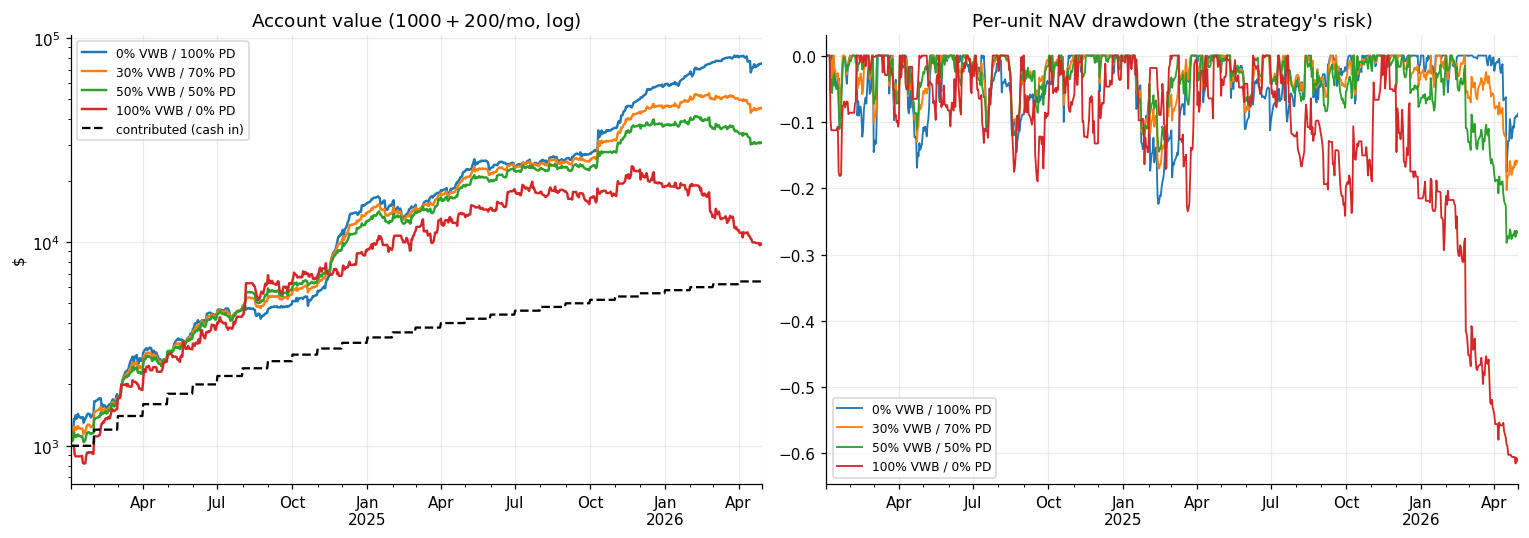

In [4]:
contrib_line = runs[0.0]["value"].copy()*0.0
# cumulative contributions over time (same schedule for all weights)
r0=runs[0.0]["ret"]; c=INIT; cl=[]; lastm=(r0.index[0].year,r0.index[0].month)
for t in r0.index:
    ym=(t.year,t.month)
    if ym!=lastm: c+=MONTHLY; lastm=ym
    cl.append(c)
contrib_line=pd.Series(cl, index=r0.index)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for w in WEIGHTS:
    lab=f"{w:.0%} VWB / {1-w:.0%} PD"
    runs[w]["value"].plot(ax=ax[0], lw=1.6, label=lab)
    (runs[w]["nav"]/runs[w]["nav"].cummax()-1).plot(ax=ax[1], lw=1.2, label=lab)
contrib_line.plot(ax=ax[0], lw=1.5, color="k", ls="--", label="contributed (cash in)")
ax[0].set_yscale("log"); ax[0].set_title("Account value ($1000 + $200/mo, log)")
ax[0].set_ylabel("$"); ax[0].legend(fontsize=8)
ax[1].set_title("Per-unit NAV drawdown (the strategy's risk)"); ax[1].legend(fontsize=8)
show("dca_12_account")

[saved] notebooks\volume_weighted_breakout\_out\dca_12_monthly.png
headline mix 30% VWB / 70% PD:
  contributed $6,400 -> $45,373  (7.1x, IRR 233%/yr)
  Sharpe 3.67  Sortino 4.73  maxDD(NAV) -20.3%  worst day -10.2%


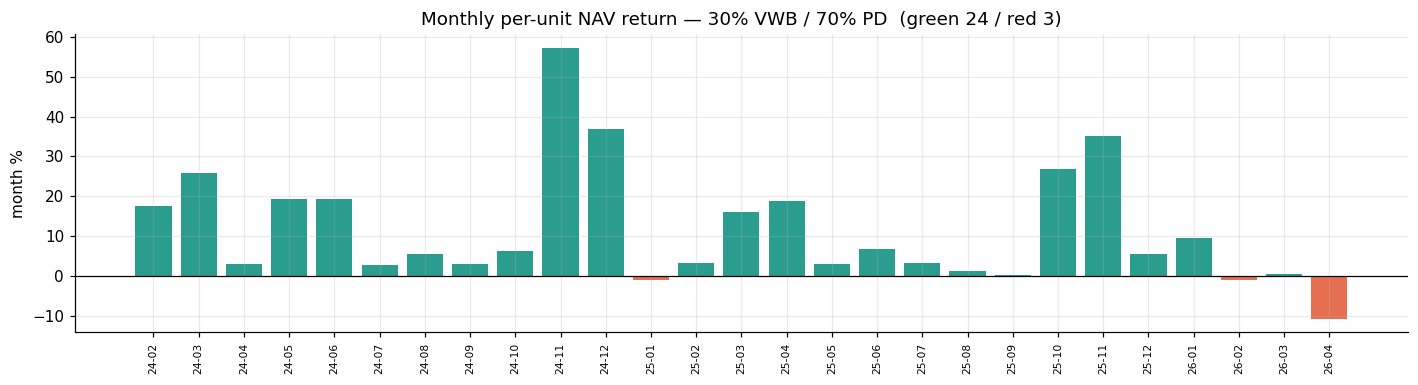

In [5]:
# monthly returns of the headline best-Sharpe mix (30% VWB / 70% PD)
HEAD=0.30
mret=(runs[HEAD]["nav"].resample("ME").last().pct_change().dropna())
fig, ax = plt.subplots(figsize=(13, 3.6))
colors=["#2a9d8f" if x>=0 else "#e76f51" for x in mret]
ax.bar(range(len(mret)), mret.values*100, color=colors)
ax.set_xticks(range(len(mret))); ax.set_xticklabels([d.strftime("%y-%m") for d in mret.index], rotation=90, fontsize=7)
ax.axhline(0, color="k", lw=0.8); ax.set_ylabel("month %")
ax.set_title(f"Monthly per-unit NAV return — {HEAD:.0%} VWB / {1-HEAD:.0%} PD  "
             f"(green {int((mret>0).sum())} / red {int((mret<0).sum())})")
show("dca_12_monthly")
print(f"headline mix {HEAD:.0%} VWB / {1-HEAD:.0%} PD:")
s=stats(runs[HEAD])
print(f"  contributed ${s['contrib_$']:,.0f} -> ${s['final_$']:,.0f}  ({s['mult']:.1f}x, IRR {s['xirr']:.0%}/yr)")
print(f"  Sharpe {s['sharpe']:.2f}  Sortino {s['sortino']:.2f}  maxDD(NAV) {s['maxDD_nav']:.1%}  worst day {s['worst_day']:.1%}")

## Verdict

Over the full 2024→2026 data, DCA'ing **$1000 + $200/mo** (≈ **$6,400 contributed**) into
the two strategies together:

- **pump_dump alone (0% VWB)** is the biggest end-balance — it is the higher-return,
  higher-variance leg (in-sample small-capital ceiling).
- **A ~30% VWB / 70% PD blend is the sweet spot** — the near-zero correlation (nb11) makes
  the combined per-unit NAV **smoother than either leg** (highest Sharpe, shallower
  drawdown) while keeping most of pump_dump's growth.
- **Adding more VWB trades return for little extra smoothing** past ~30%, and **VWB 3x
  alone** is the weakest DCA (low multiple, deep drawdown) — 3x leverage on a 4h breakout
  is volatile without pump_dump to diversify it.

**Read the dollars as an in-sample ceiling, not a forecast.** Both legs are fit on one
2024→2026 window with no true alt-mania; pump8/dump3 is the aggressive tilt (worst single
trade −37%, gap tail the stop can't touch), VWB's 3x is an arbitrary risk dial, capacity
binds harder as the account grows, and daily rebalancing between a microcap 1m engine and a
4h majors bot is idealized. The durable result is the *shape*: **independent positive-
expectancy streams DCA'd together beat either alone on risk-adjusted terms, with the
Sharpe/drawdown optimum around a 30% VWB tilt.**